<a href="https://colab.research.google.com/github/vivpatel27-bit/ml-projects/blob/main/NBAPlayoffPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.) Importing Data from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")

print("Path to dataset files:", path)

100%|██████████| 10.6M/10.6M [00:02<00:00, 5.45MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumitrodatta/nba-aba-baa-stats/versions/56


In [2]:
import os

for file in os.listdir(path):
    print(file)

End of Season Teams (Voting).csv
Player Season Info.csv
Team Abbrev.csv
Opponent Stats Per Game.csv
Per 36 Minutes.csv
Draft Pick History.csv
Player Shooting.csv
End of Season Teams.csv
Player Award Shares.csv
Team Stats Per Game.csv
Player Career Info.csv
Per 100 Poss.csv
All-Star Selections.csv
Team Totals.csv
Player Totals.csv
Team Summaries.csv
Opponent Stats Per 100 Poss.csv
Team Stats Per 100 Poss.csv
Advanced.csv
Player Play By Play.csv
Player Per Game.csv
Opponent Totals.csv


In [3]:
import pandas as pd

df = pd.read_csv(path + '/Team Stats Per Game.csv')
df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Atlanta Hawks,ATL,False,82.0,240.9,43.6,92.0,0.474,...,0.774,11.0,32.6,43.5,30.1,9.4,4.7,14.2,19.7,118.5
1,2026,NBA,Boston Celtics,BOS,False,82.0,240.6,42.1,90.2,0.467,...,0.807,12.5,33.9,46.4,24.6,7.1,5.0,12.4,19.0,114.9
2,2026,NBA,Brooklyn Nets,BRK,False,82.0,240.9,37.5,84.5,0.443,...,0.780,10.3,29.0,39.3,25.0,8.0,4.3,15.8,21.1,105.9
3,2026,NBA,Chicago Bulls,CHI,False,82.0,240.9,42.4,90.5,0.469,...,0.776,10.4,34.7,45.0,28.5,7.6,5.0,15.3,19.0,116.3
4,2026,NBA,Charlotte Hornets,CHO,False,82.0,240.9,40.9,88.9,0.460,...,0.818,12.8,33.3,46.1,26.3,7.0,4.5,15.4,19.1,116.0


2.) Cleaning Data

In [4]:
df = df.drop(columns = ["lg", "abbreviation"])
df.columns

Index(['season', 'team', 'playoffs', 'g', 'mp_per_game', 'fg_per_game',
       'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game',
       'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent',
       'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game',
       'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game',
       'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game'],
      dtype='object')

In [5]:
df = pd.get_dummies(df, columns=['team'], drop_first=True)

In [6]:
df

,season,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,...,team_Toronto Raptors,team_Tri-Cities Blackhawks,team_Utah Jazz,team_Utah Stars,team_Vancouver Grizzlies,team_Virginia Squires,team_Washington Bullets,team_Washington Capitols,team_Washington Wizards,team_Waterloo Hawks
0,2026,False,82.0,240.9,43.6,92.0,0.474,14.6,39.5,0.371,...,False,False,False,False,False,False,False,False,False,False
1,2026,False,82.0,240.6,42.1,90.2,0.467,15.5,42.1,0.367,...,False,False,False,False,False,False,False,False,False,False
2,2026,False,82.0,240.9,37.5,84.5,0.443,13.1,38.4,0.340,...,False,False,False,False,False,False,False,False,False,False
3,2026,False,82.0,240.9,42.4,90.5,0.469,14.3,40.1,0.356,...,False,False,False,False,False,False,False,False,False,False
4,2026,False,82.0,240.9,40.9,88.9,0.460,16.4,43.3,0.378,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902,1947,False,60.0,NaN,27.2,93.0,0.292,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1903,1947,True,61.0,NaN,26.2,96.3,0.272,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1904,1947,False,60.0,NaN,25.3,94.5,0.267,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1905,1947,True,60.0,NaN,28.7,96.6,0.297,NaN,NaN,NaN,...,False,False,False,False,False,False,False,True,False,False


In [7]:
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"Dropped {before - after} rows ({before} → {after})")

Dropped 512 rows (1907 → 1395)


In [8]:
df

,season,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,...,team_Toronto Raptors,team_Tri-Cities Blackhawks,team_Utah Jazz,team_Utah Stars,team_Vancouver Grizzlies,team_Virginia Squires,team_Washington Bullets,team_Washington Capitols,team_Washington Wizards,team_Waterloo Hawks
0,2026,False,82.0,240.9,43.6,92.0,0.474,14.6,39.5,0.371,...,False,False,False,False,False,False,False,False,False,False
1,2026,False,82.0,240.6,42.1,90.2,0.467,15.5,42.1,0.367,...,False,False,False,False,False,False,False,False,False,False
2,2026,False,82.0,240.9,37.5,84.5,0.443,13.1,38.4,0.340,...,False,False,False,False,False,False,False,False,False,False
3,2026,False,82.0,240.9,42.4,90.5,0.469,14.3,40.1,0.356,...,False,False,False,False,False,False,False,False,False,False
4,2026,False,82.0,240.9,40.9,88.9,0.460,16.4,43.3,0.378,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,1974,True,84.0,241.8,42.7,88.4,0.483,1.1,4.1,0.272,...,False,False,False,True,False,False,False,False,False,False
1498,1974,True,84.0,241.2,40.8,90.3,0.452,0.9,3.4,0.262,...,False,False,False,False,False,True,False,False,False,False
1499,1974,False,84.0,241.7,42.9,93.3,0.460,1.2,4.2,0.283,...,False,False,False,False,False,False,False,False,False,False
1520,1973,True,84.0,238.6,40.9,89.3,0.458,0.9,3.6,0.246,...,False,False,False,False,False,False,False,False,False,False


3.) EDA

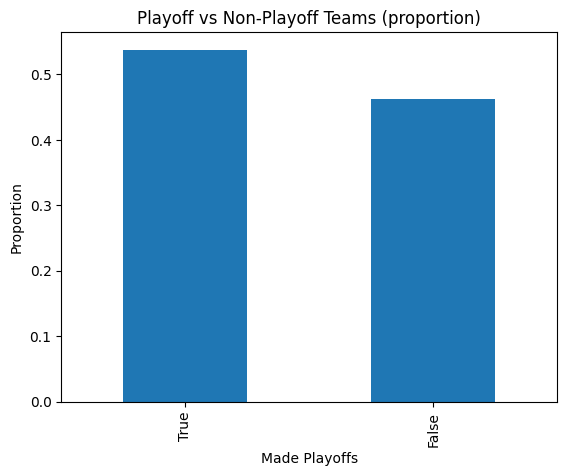

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df['playoffs'].value_counts(normalize=True).plot(kind='bar')
plt.title('Playoff vs Non-Playoff Teams (proportion)')
plt.xlabel('Made Playoffs')
plt.ylabel('Proportion')
plt.show()

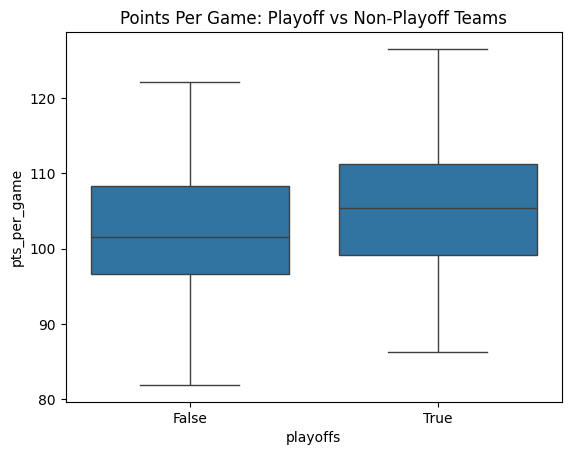

In [10]:
sns.boxplot(data=df, x='playoffs', y='pts_per_game')
plt.title('Points Per Game: Playoff vs Non-Playoff Teams')
plt.show()

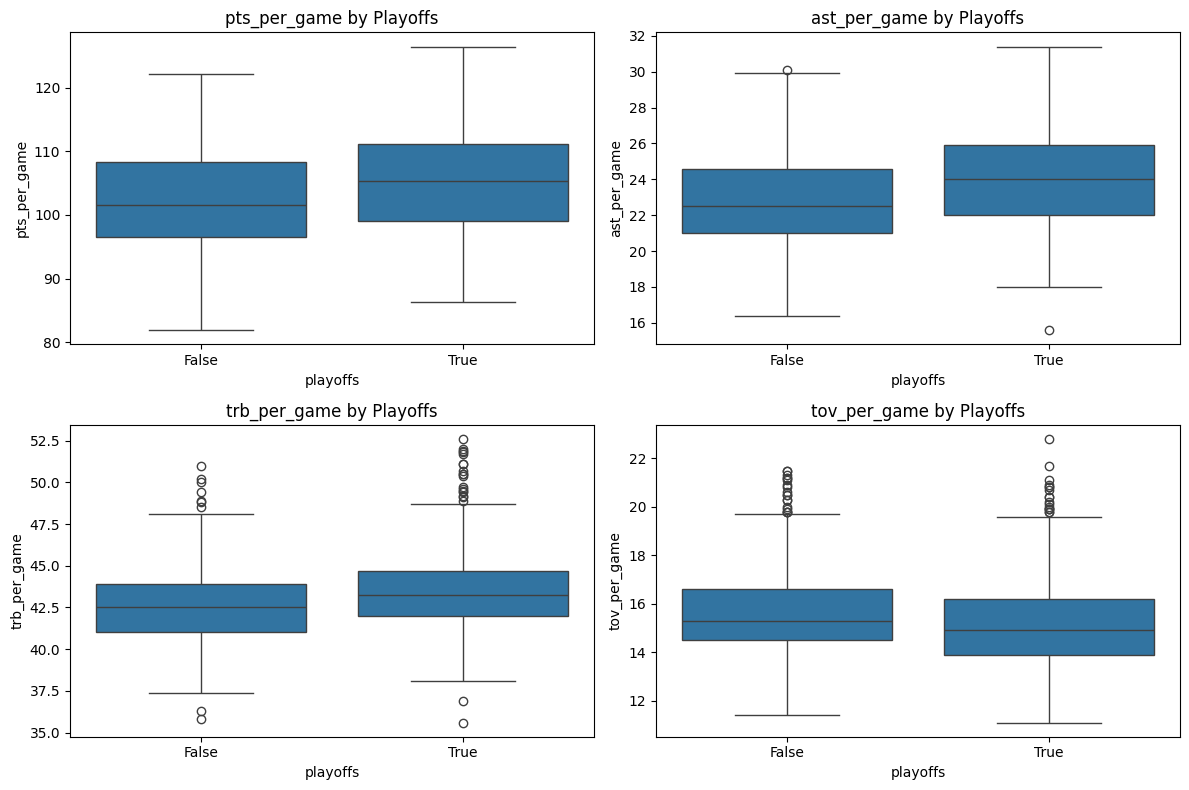

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
stats_to_check = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'tov_per_game']

for ax, stat in zip(axes.flat, stats_to_check):
    sns.boxplot(data=df, x='playoffs', y=stat, ax=ax)
    ax.set_title(f'{stat} by Playoffs')

plt.tight_layout()
plt.show()

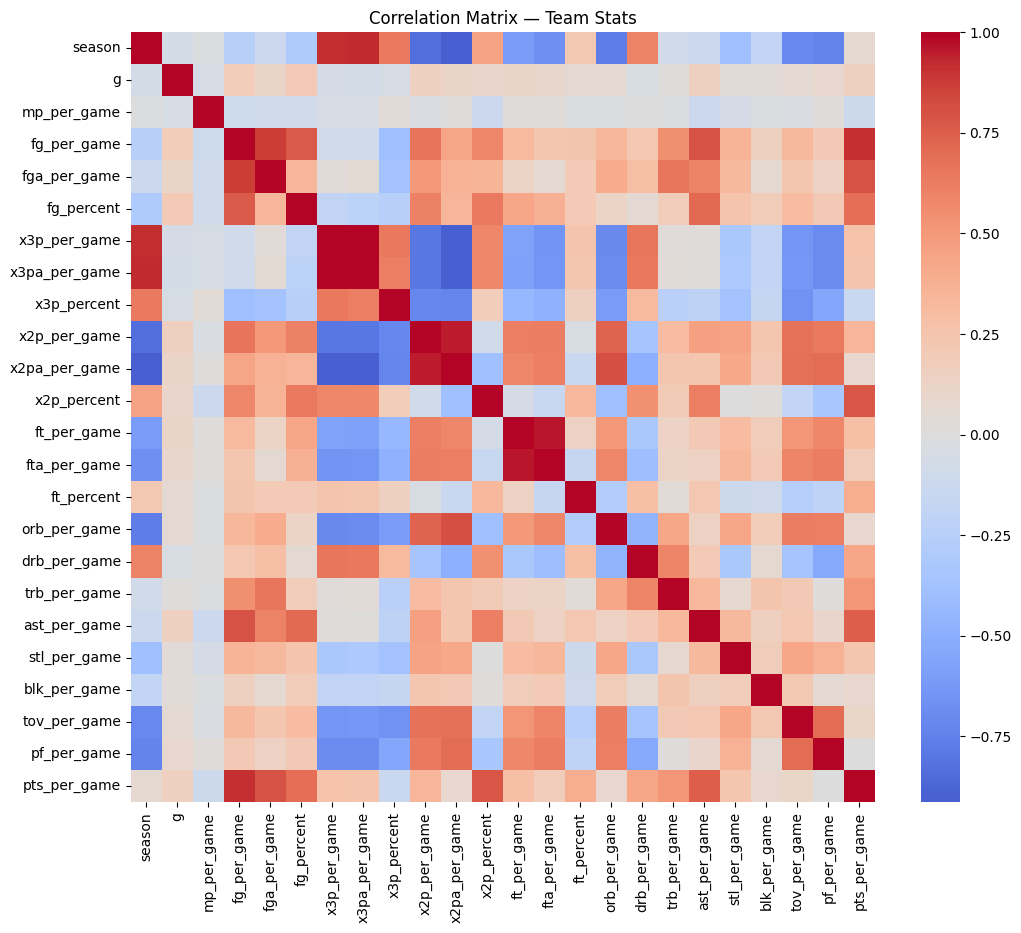

In [12]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix — Team Stats')
plt.show()

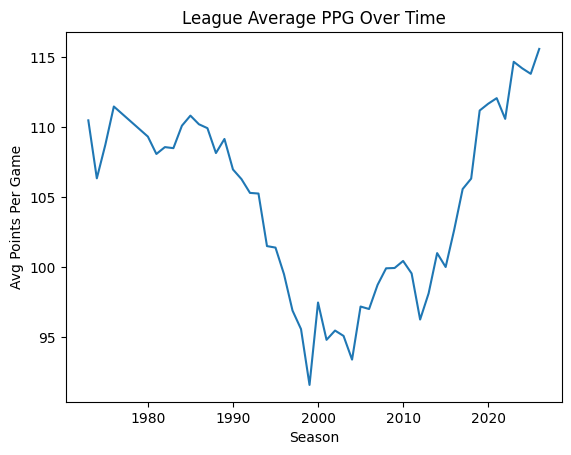

In [13]:
df.groupby('season')['pts_per_game'].mean().plot()
plt.title('League Average PPG Over Time')
plt.xlabel('Season')
plt.ylabel('Avg Points Per Game')
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1395 entries, 0 to 1528
Columns: 121 entries, season to team_Waterloo Hawks
dtypes: bool(97), float64(23), int64(1)
memory usage: 404.6 KB


In [15]:
df.describe()

,season,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,x3p_per_game,x3pa_per_game,x3p_percent,x2p_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
count,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,...,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000
mean,2003.393548,80.415054,241.668459,39.307599,84.817993,0.463032,6.057778,17.132545,0.335300,33.253118,...,0.758424,12.242867,30.808674,43.049677,23.476631,8.031254,5.034265,15.391685,21.943943,103.868315
std,13.865177,6.125697,0.828982,3.298260,4.879868,0.020490,4.081760,11.015799,0.045771,5.462378,...,0.029393,2.095585,2.348589,2.300235,2.664685,1.082626,0.922811,1.867102,2.427242,7.776629
min,1973.000000,11.000000,238.600000,30.800000,71.200000,0.401000,0.100000,0.900000,0.104000,23.100000,...,0.660000,7.600000,24.900000,35.600000,15.600000,1.900000,0.400000,11.100000,15.500000,81.900000
25%,1992.000000,82.000000,241.200000,36.600000,81.200000,0.448000,2.800000,8.200000,0.323000,29.400000,...,0.741000,10.700000,29.100000,41.500000,21.400000,7.300000,4.400000,14.100000,20.200000,97.700000
50%,2004.000000,82.000000,241.500000,39.100000,85.000000,0.462000,5.600000,15.800000,0.348000,31.300000,...,0.759000,12.000000,30.500000,42.900000,23.400000,7.900000,4.900000,15.100000,21.700000,103.500000
75%,2015.000000,82.000000,242.100000,41.900000,88.350000,0.476000,8.650000,24.150000,0.364000,37.750000,...,0.778000,13.600000,32.400000,44.400000,25.400000,8.700000,5.500000,16.400000,23.600000,110.000000
max,2026.000000,84.000000,244.900000,48.500000,108.100000,0.545000,17.800000,48.200000,0.428000,48.200000,...,0.839000,19.900000,42.200000,52.600000,31.400000,12.800000,8.700000,22.800000,29.700000,126.500000


3.) Modelling

In [16]:
#Splitting our data
from sklearn.model_selection import train_test_split
import numpy as np

#Define features and target
X = df.drop('playoffs', axis=1)
y = df['playoffs']

#Split - 80% train, 20% test
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1116, 120) (279, 120)


In [17]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Put models in a dictionary
models = {"Logisitc Regression": LogisticRegression(),
          "XGBoost": XGBClassifier(),
          "Random Forest": RandomForestClassifier()}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    # Set random seed
    np.random.seed(42)
    # Make a dictionary to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Get predictions, then compute F1
        preds = model.predict(X_test)
        model_scores[name] = f1_score(y_test, preds)
    return model_scores


model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

model_scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logisitc Regression': 0.7656765676567657,
 'XGBoost': 0.8553054662379421,
 'Random Forest': 0.8013468013468014}

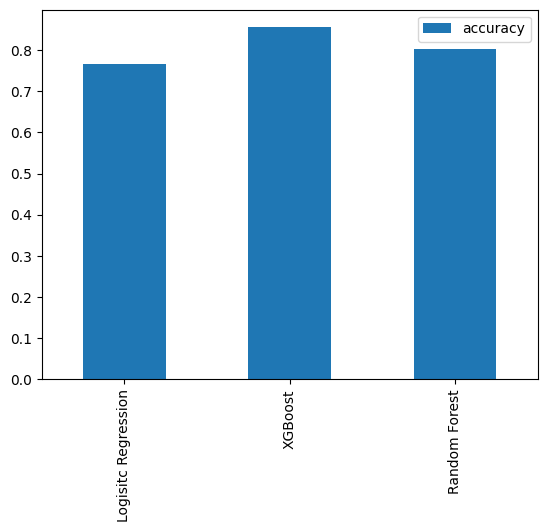

In [18]:
model_compare = pd.DataFrame(model_scores, index=["F1 Score"])
model_compare.T.plot.bar();

4.) XGBoost - Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Handle imbalance if needed - check your class balance first
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

# Stratified CV keeps class ratio consistent across folds - important for imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',        # not 'accuracy' - same reasoning as before, imbalance makes accuracy misleading
    cv=cv,
    n_jobs=-1,            # use all available cores
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}
Best CV F1: 0.845270828350157


6.) Evaluation

In [24]:
# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

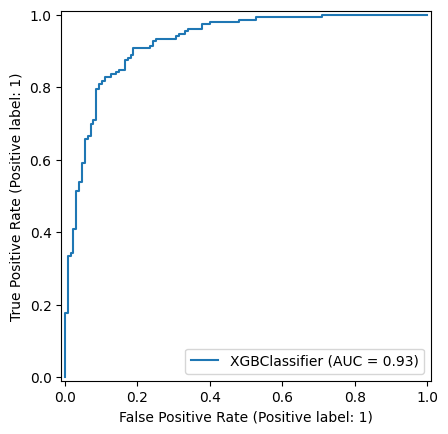

In [25]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

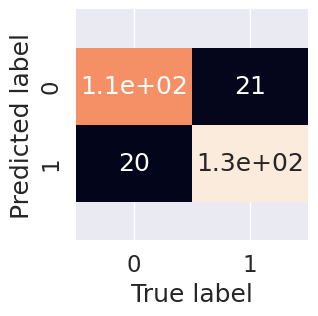

In [27]:
y_preds = best_model.predict(X_test)

sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")

    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)

plot_conf_mat(y_test, y_preds)

In [29]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       False       0.84      0.83      0.84       127
        True       0.86      0.87      0.87       152

    accuracy                           0.85       279
   macro avg       0.85      0.85      0.85       279
weighted avg       0.85      0.85      0.85       279

